# RF Model

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, r2_score

## Data Stuff

In [45]:
#BRING IN THE MOTHER
mother_file = pd.read_csv("data/mother2.csv")
#michelena test
#mother_file = pd.read_csv("data/mother_with_salaries.csv")
mother_file

# removing a ton of columns that are not helpful
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_value_tonnes' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'capacity_value' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_total_material' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_grade' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_mineral_value' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_commodity_value' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'commodities_grade' in col])
mother_file

,facility_id,primary_commodity,country,LOM_in_Buckets,still_operating,price_usd_tonne,2000_clean_coal_value_tonnes,2001_clean_coal_value_tonnes,2002_clean_coal_value_tonnes,2003_clean_coal_value_tonnes,...,2011_minerals_ore_processed_value_tonnes,2012_minerals_ore_processed_value_tonnes,2013_minerals_ore_processed_value_tonnes,2014_minerals_ore_processed_value_tonnes,2015_minerals_ore_processed_value_tonnes,2016_minerals_ore_processed_value_tonnes,2017_minerals_ore_processed_value_tonnes,2018_minerals_ore_processed_value_tonnes,2019_minerals_ore_processed_value_tonnes,2020_minerals_ore_processed_value_tonnes
0,COM00003.00,Coal,United States of America,47.0,1.0,43.21,NaN,5356109.0,4681152.0,5457715.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,COM00008.00,Nickel,Spain,11.0,0.0,16811.81,NaN,NaN,NaN,NaN,...,0.0,577000.0,1606000.0,1660000.0,1292000.0,NaN,NaN,NaN,NaN,NaN
2,COM00009.00,Gold,Ghana,15.0,1.0,672.01,NaN,NaN,NaN,NaN,...,7814621.0,7605965.0,7774704.0,7004491.0,6637075.0,7269394.0,6904699.0,6367637.0,6620746.0,NaN
3,COM00015.00,Copper,Kazakhstan,6.0,1.0,5630.38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3003000.0,15989000.0,13040000.0,16104000.0,NaN,NaN
4,COM00016.00,Gold,Ghana,8.0,1.0,1286.07,NaN,NaN,NaN,NaN,...,NaN,NaN,1613002.0,7731158.0,7249435.0,8415187.0,8412466.0,7771075.0,7856352.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,COM01415.00,Coal,Russian Federation,68.0,1.0,67.27,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
398,COM01418.00,Gold,Tajikistan,14.0,1.0,1514.58,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
399,COM01419.00,Coal,China,12.0,1.0,70.77,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
400,COM01430.00,Gold,China,41.0,1.0,456.56,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# Split on facility_id
facilities = mother_file["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

train_df = mother_file[mother_file["facility_id"].isin(train_facilities)]
test_df  = mother_file[mother_file["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
y_train = train_df["LOM_in_Buckets"]
y_test  = test_df["LOM_in_Buckets"]

# Drop unwanted columns (found after other data processing steps)to create feature matrices

X_train = train_df.select_dtypes(include="number")
X_test  = test_df.select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = y_train.notna()
mask_test  = y_test.notna()
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test,  y_test  = X_test[mask_test],  y_test[mask_test]

# Fill NaNs in features with training median
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print(f"\nFeatures used : {list(X_train.columns)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")

Train rows : 321 (321 facilities)
Test rows  : 81 (81 facilities)

Features used : ['LOM_in_Buckets', 'still_operating', 'price_usd_tonne', '2000_clean_coal_value_tonnes', '2001_clean_coal_value_tonnes', '2002_clean_coal_value_tonnes', '2003_clean_coal_value_tonnes', '2004_clean_coal_value_tonnes', '2005_clean_coal_value_tonnes', '2006_clean_coal_value_tonnes', '2007_clean_coal_value_tonnes', '2008_clean_coal_value_tonnes', '2009_clean_coal_value_tonnes', '2010_clean_coal_value_tonnes', '2011_clean_coal_value_tonnes', '2012_clean_coal_value_tonnes', '2013_clean_coal_value_tonnes', '2014_clean_coal_value_tonnes', '2015_clean_coal_value_tonnes', '2016_clean_coal_value_tonnes', '2017_clean_coal_value_tonnes', '2018_clean_coal_value_tonnes', '2019_clean_coal_value_tonnes', '2020_clean_coal_value_tonnes', '2000_coal_mined_value_tonnes', '2001_coal_mined_value_tonnes', '2002_coal_mined_value_tonnes', '2003_coal_mined_value_tonnes', '2004_coal_mined_value_tonnes', '2005_coal_mined_value_tonne

In [47]:
# we're having some trouble with X, let's see what it is -- as it turns out, some values were infinite
print(X_train)
pd.DataFrame(X_train).to_csv('data/X_train_check.csv', index=False)

     LOM_in_Buckets  still_operating  price_usd_tonne  \
1              11.0              0.0         16811.81   
2              15.0              1.0           672.01   
4               8.0              1.0          1286.07   
6              10.0              0.0            14.03   
7              57.0              1.0            85.86   
..              ...              ...              ...   
392            24.0              1.0            68.48   
394            29.0              1.0            36.19   
395            33.0              1.0            75.08   
399            12.0              1.0            70.77   
401           164.0              1.0          1156.66   

     2000_clean_coal_value_tonnes  2001_clean_coal_value_tonnes  \
1                       4404000.0                     3332960.0   
2                       4404000.0                     3332960.0   
4                       4404000.0                     3332960.0   
6                       4404000.0              

## Model Stuff

In [48]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
# print(y_pred_train)
# print(y_pred_test)

print('R^2 train:', r2_score(y_train, y_pred_train))
print('R^2 test :', r2_score(y_test, y_pred_test))

# accuracy_train_grid = accuracy_score(y_train, y_pred_train)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test)


R^2 train: 0.9608414310055239
R^2 test : 0.9231010479040991


In [49]:
# # adapted from Pset 1 Q3 and Pset 3 Q3
param_grid = {
    'max_depth': (1, 3, 5, 10),
    'min_samples_leaf': (1, 5, 20)
    # 'criterion': (“squared_error”, “absolute_error”, “friedman_mse”, “poisson”)
}

tree = RandomForestRegressor()
grid_tree = GridSearchCV(estimator=tree,
                         param_grid=param_grid,
                         scoring='r2',
                         cv=5)

grid_tree.fit(X_train,y_train)
grid_model = grid_tree.best_estimator_

y_pred_train_grid = grid_model.predict(X_train)
y_pred_test_grid = grid_model.predict(X_test)

# accuracy_train_grid = accuracy_score(y_train, y_pred_train_grid)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test_grid)

print("best accuracy", grid_tree.best_score_)
print("best params", grid_tree.best_params_)
print('Grid R^2 train:', r2_score(y_train, y_pred_train_grid))
print('Grid R^2 test :', r2_score(y_test, y_pred_test_grid))


# print(f'Train Accuracy = {accuracy_train_grid}')
# print(f'Test Accuracy = {accuracy_test_grid}')


best accuracy 0.8531914329215589
best params {'max_depth': 3, 'min_samples_leaf': 5}
Grid R^2 train: 0.7278319443542565
Grid R^2 test : 0.9544651301427379


## Plotting Stuff

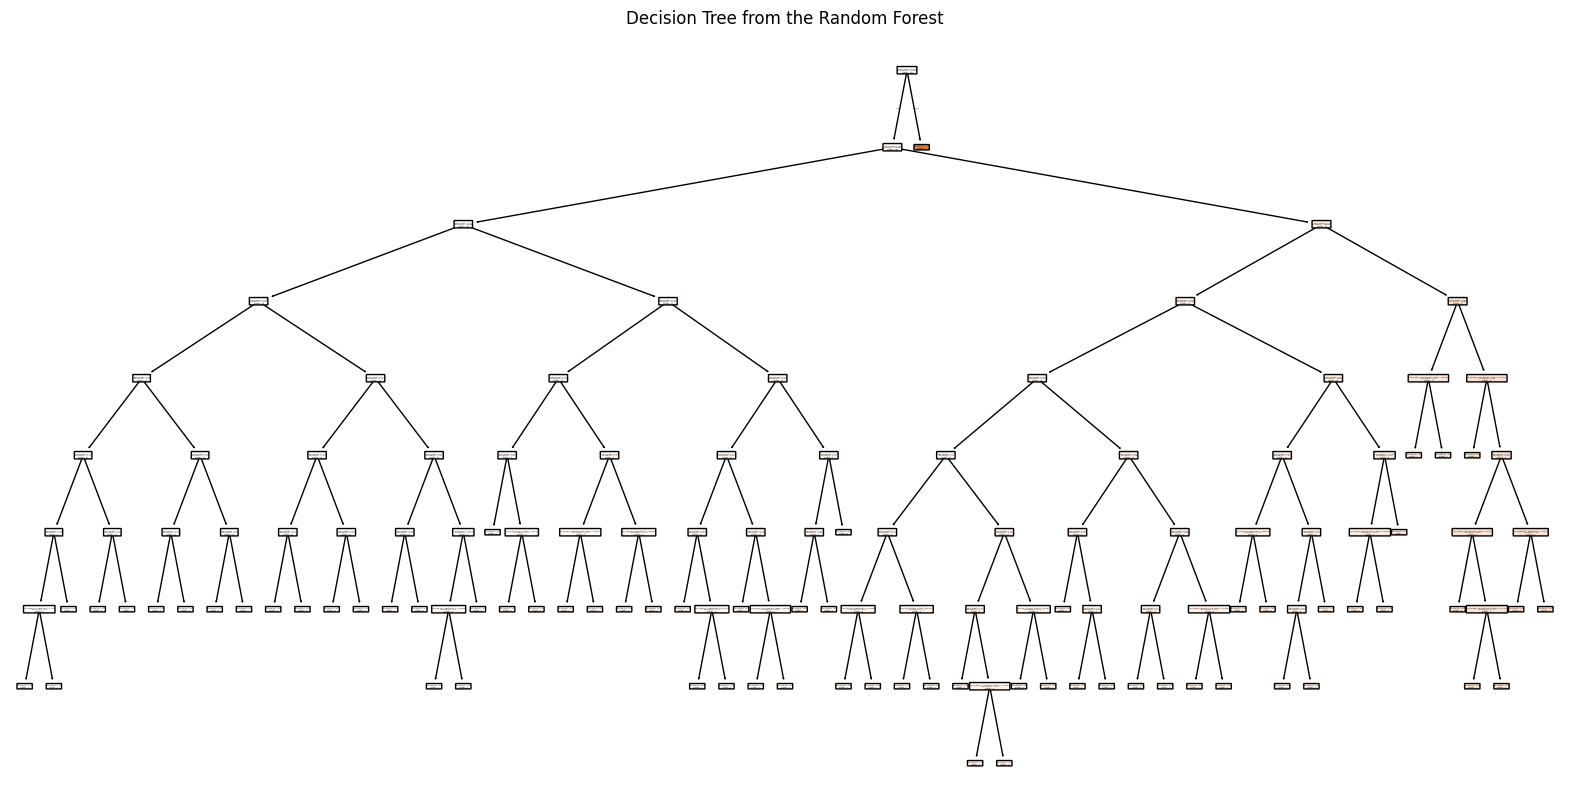

In [50]:
tree = model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             # make things pretty
plt.title("Decision Tree from the Random Forest")
plt.show()

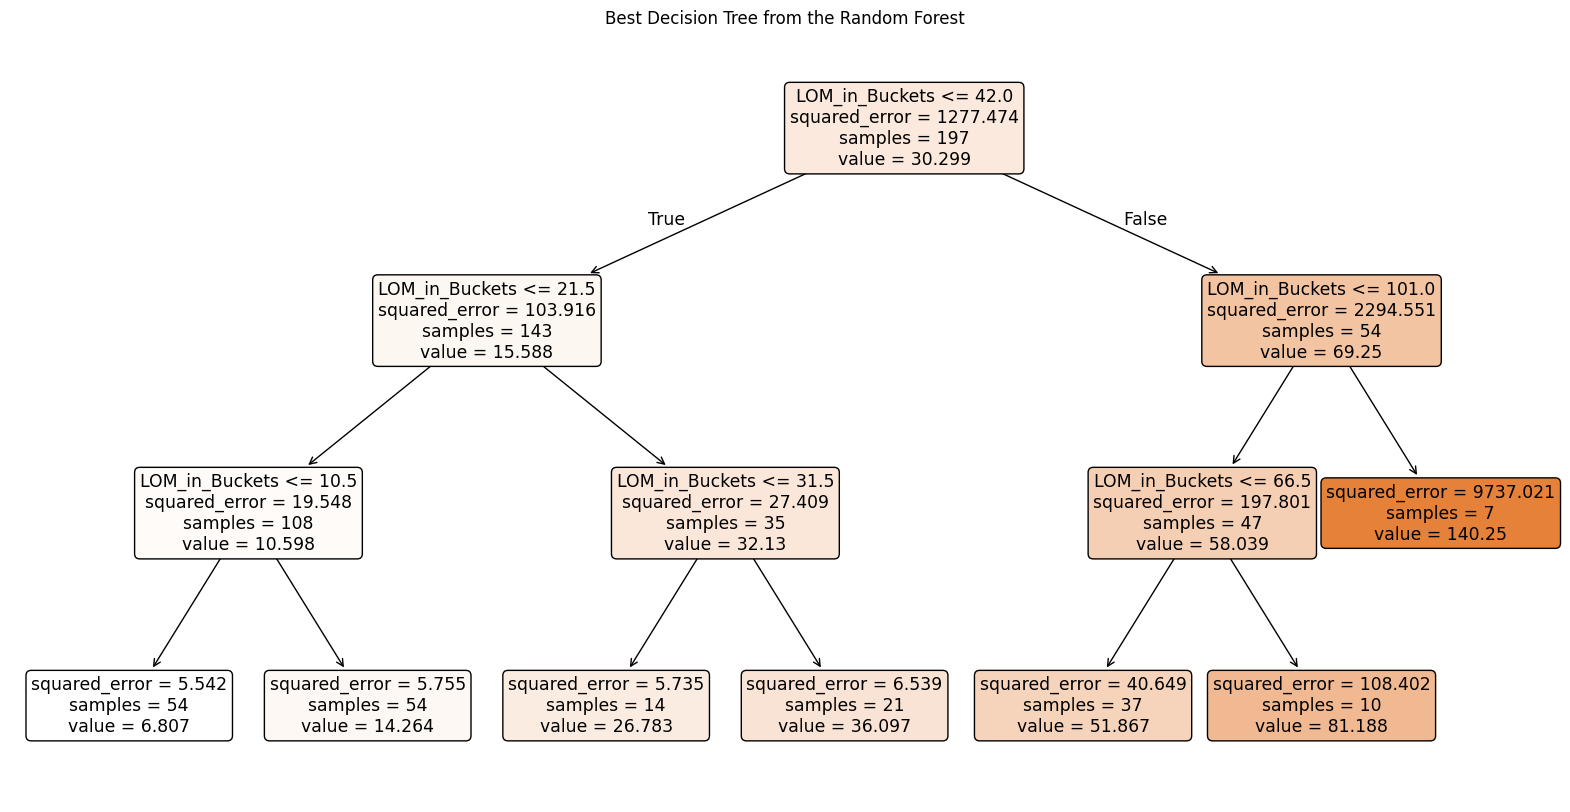

In [51]:
grid_tree = grid_model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(grid_tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             
plt.title("Best Decision Tree from the Random Forest")
plt.show()